1. Import Libraries
In this section, we import the necessary libraries. numpy and random are used for matrix operations and epsilon-greedy exploration. matplotlib.pyplot is used to plot the evaluation results later.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

2. Game Environment Setup
Here we define the Tic-Tac-Toe environment. This class manages the state space (the 3x3 board) and the action space (available empty spots). It checks for wins, draws, and updates the board state.

In [2]:
class TicTacToe:
    def __init__(self):
        self.board = [' '] * 9 # 3x3 board represented as a flat list
        self.current_winner = None

    def print_board(self):
        for row in [self.board[i*3:(i+1)*3] for i in range(3)]:
            print('| ' + ' | '.join(row) + ' |')

    def available_moves(self):
        return [i for i, spot in enumerate(self.board) if spot == ' ']

    def make_move(self, square, letter):
        if self.board[square] == ' ':
            self.board[square] = letter
            if self.winner(square, letter):
                self.current_winner = letter
            return True
        return False

    def winner(self, square, letter):
        # Check rows
        row_ind = square // 3
        row = self.board[row_ind*3 : (row_ind+1)*3]
        if all([spot == letter for spot in row]): return True
        # Check columns
        col_ind = square % 3
        column = [self.board[col_ind+i*3] for i in range(3)]
        if all([spot == letter for spot in column]): return True
        # Check diagonals
        if square % 2 == 0:
            diagonal1 = [self.board[i] for i in [0, 4, 8]]
            if all([spot == letter for spot in diagonal1]): return True
            diagonal2 = [self.board[i] for i in [2, 4, 6]]
            if all([spot == letter for spot in diagonal2]): return True
        return False

    def get_state(self):
        return tuple(self.board)

3. Q-Learning AgentThis class implements the tabular Q-learning algorithm. It uses a dictionary to store Q-values for state-action pairs. It balances exploration and exploitation using the $\epsilon$-greedy strategy and updates its policy using the Bellman equation to maximize cumulative rewards.

In [4]:
class QLearningAgent:
    def __init__(self, alpha=0.5, gamma=0.9, epsilon=0.2):
        self.q_table = {}
        self.alpha = alpha # Learning rate
        self.gamma = gamma # Discount factor
        self.epsilon = epsilon # Exploration rate

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0.0)

    def choose_action(self, state, available_moves):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(available_moves) # Explore

        q_values = [self.get_q_value(state, a) for a in available_moves]
        max_q = max(q_values)
        best_actions = [a for a in available_moves if self.get_q_value(state, a) == max_q]
        return random.choice(best_actions) # Exploit

    def learn(self, state, action, reward, next_state, next_available_moves):
        current_q = self.get_q_value(state, action)
        max_next_q = max([self.get_q_value(next_state, a) for a in next_available_moves]) if next_available_moves else 0.0
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(state, action)] = new_q

4. Training Phase and Evaluation
We train the agent for 10,000 episodes against an opponent making random valid moves. The agent receives +10 for winning, -10 for losing, and +5 for a draw. We then plot the win rate to visualize the learning progress.

Training Agent... Please wait.
Training Complete! Final Epsilon: 0.0100


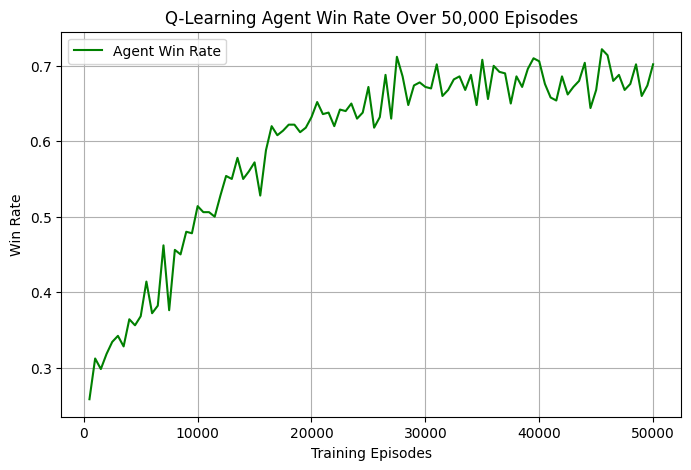

In [7]:
print("Training Agent... Please wait.")
train_agent = QLearningAgent(epsilon=1.0) # Start with 100% exploration
episodes = 50000
batch_size = 500
win_rates = []
agent_wins = 0

for ep in range(episodes):
    # Core Improvement 1: Epsilon Decay (gradually decrease exploration)
    train_agent.epsilon = max(0.01, train_agent.epsilon * 0.9999)
    env = TicTacToe()
    last_state_action = None

    while True:
        # Core Improvement 2: Self-Play Proxy
        # Opponent 'X' moves randomly 30% of the time, and uses Agent's Q-table 70% of the time
        if random.uniform(0, 1) < 0.3:
            x_action = random.choice(env.available_moves())
        else:
            x_action = train_agent.choose_action(env.get_state(), env.available_moves())

        env.make_move(x_action, 'X')

        if env.current_winner == 'X':
            if last_state_action:
                train_agent.learn(last_state_action[0], last_state_action[1], -10, env.get_state(), [])
            break
        elif not env.available_moves():
            if last_state_action:
                train_agent.learn(last_state_action[0], last_state_action[1], 5, env.get_state(), [])
            break

        # Agent 'O' Turn
        state = env.get_state()
        available = env.available_moves()
        action = train_agent.choose_action(state, available)
        env.make_move(action, 'O')
        next_state = env.get_state()

        if env.current_winner == 'O':
            train_agent.learn(state, action, 10, next_state, [])
            agent_wins += 1
            break
        elif not env.available_moves():
            train_agent.learn(state, action, 5, next_state, [])
            break
        else:
            train_agent.learn(state, action, 0, next_state, env.available_moves())

        last_state_action = (state, action)

    if (ep + 1) % batch_size == 0:
        win_rates.append(agent_wins / batch_size)
        agent_wins = 0

print(f"Training Complete! Final Epsilon: {train_agent.epsilon:.4f}")

# Plotting the Evaluation Results
plt.figure(figsize=(8, 5))
plt.plot(range(batch_size, episodes + 1, batch_size), win_rates, label='Agent Win Rate (Self-Play)', color='purple')
plt.title('Q-Learning Agent Win Rate Over 50,000 Episodes')
plt.xlabel('Training Episodes')
plt.ylabel('Win Rate')
plt.grid(True)
plt.legend()
plt.show()

5. Game Interaction (Human vs Agent)Now you can play against the trained agent! The exploration rate ($\epsilon$) is set to 0.0 so the agent purely exploits its learned policy. Inputs are integers from 0 to 8 corresponding to the grid spots.

In [9]:
print("\n--- Let's Play! You are X, Agent is O ---")
print("Positions are 0-8 from top-left to bottom-right.")
train_agent.epsilon = 0.0 # Turn off exploration for evaluation

env = TicTacToe()
env.print_board()

while True:
    # Human Turn
    valid_move = False
    while not valid_move:
        try:
            user_input = input(f"Choose your move {env.available_moves()} (or type 'q' to quit): ")
            if user_input.lower() == 'q':
                print("Game ended by user.")
                break
            move = int(user_input)
            if move in env.available_moves():
                valid_move = True
            else:
                print("Invalid move. Spot already taken or out of range. Try again.")
        except ValueError:
            print("Please enter a valid integer.")

    if user_input.lower() == 'q': break

    env.make_move(move, 'X')
    env.print_board()

    if env.current_winner == 'X':
        print("You Win! Agent got a negative penalty.")
        break
    elif not env.available_moves():
        print("It's a Draw! Agent learned to defend.")
        break

    # Agent Turn
    print("\nAgent is making a move...")
    state = env.get_state()
    action = train_agent.choose_action(state, env.available_moves())
    env.make_move(action, 'O')
    env.print_board()

    if env.current_winner == 'O':
        print("Agent Wins! Agent successfully exploited its Q-table.")
        break
    elif not env.available_moves():
        print("It's a Draw! Agent learned to defend.")
        break


--- Let's Play! You are X, Agent is O ---
Positions are 0-8 from top-left to bottom-right.
|   |   |   |
|   |   |   |
|   |   |   |
Choose your move [0, 1, 2, 3, 4, 5, 6, 7, 8] (or type 'q' to quit): 4
|   |   |   |
|   | X |   |
|   |   |   |

Agent is making a move...
|   |   |   |
|   | X |   |
| O |   |   |
Choose your move [0, 1, 2, 3, 5, 7, 8] (or type 'q' to quit): 8
|   |   |   |
|   | X |   |
| O |   | X |

Agent is making a move...
| O |   |   |
|   | X |   |
| O |   | X |
Choose your move [1, 2, 3, 5, 7] (or type 'q' to quit): 3
| O |   |   |
| X | X |   |
| O |   | X |

Agent is making a move...
| O |   |   |
| X | X | O |
| O |   | X |
Choose your move [1, 2, 7] (or type 'q' to quit): 2
| O |   | X |
| X | X | O |
| O |   | X |

Agent is making a move...
| O |   | X |
| X | X | O |
| O | O | X |
Choose your move [1] (or type 'q' to quit): 1
| O | X | X |
| X | X | O |
| O | O | X |
It's a Draw! Agent learned to defend.
